# Feature Engineering and Modelling

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

## Load data

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


## Modelling
`Random Forest`

In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

In [5]:
# copy of data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

#### Hyperparameter choices

- `n_estimators=1000`
- `random_state=42`
- `n_jobs=-1`

In [7]:
# Train the random forest classifier
model = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

### Evaluation

In [8]:
# Generate predictions on the held-out test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

# Quick look at a few predictions vs. actual outcomes
results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'churn_probability': y_pred_proba
})
results.head(10)


,actual,predicted,churn_probability
0,0,0,0.119
1,0,0,0.167
2,0,0,0.042
3,0,0,0.084
4,0,0,0.030
5,0,0,0.062
6,0,0,0.020
7,1,0,0.248
8,0,0,0.023
9,0,0,0.037


In [9]:
# Calculate performance metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")


Accuracy:  0.904
Precision: 0.850
Recall:    0.046
F1-score:  0.088


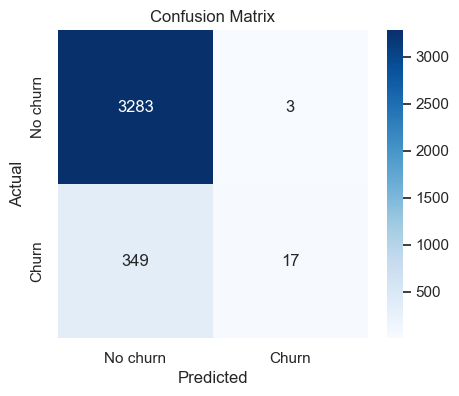

In [10]:
# Confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No churn', 'Churn'], yticklabels=['No churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [11]:
# Compare against a naive baseline
# whether the accuracy number above is actually good
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

print(f"Naive baseline accuracy (always predict majority class): {baseline_accuracy:.3f}")
print(f"Model accuracy:                                          {accuracy:.3f}")
print(f"Improvement over baseline:                                {(accuracy - baseline_accuracy):+.3f}")


Naive baseline accuracy (always predict majority class): 0.900
Model accuracy:                                          0.904
Improvement over baseline:                                +0.004


In [16]:
# discussion grounded in the actual numbers above
from IPython.display import Markdown, display

recall_comment = (
    "is catching a meaningful majority of customers who actually churn"
    if recall >= 0.5 else
    "is currently missing more than half of the customers who actually churn, "
    "which is a significant gap given how costly losing a customer is"
)
precision_comment = (
    "most of the customers it flags as at-risk are genuine churners, so "
    "retention spend based on these flags would mostly be well targeted"
    if precision >= 0.5 else
    "a large share of the customers it flags as at-risk would not actually "
    "have churned, so retention spend based on these flags would be inefficient"
)
verdict = (
    "This is a reasonable starting point to act on, though there's still room "
    "to improve recall before fully relying on it to drive retention spend."
    if recall >= 0.5 and precision >= 0.3 else
    "This is a useful first iteration but not yet strong enough to act on "
    "directly. Worth trying `class_weight='balanced'`, tuning the "
    "classification threshold (the default 0.5 cutoff isn't necessarily "
    "optimal on imbalanced data), or gathering more churn examples."
)

summary = f'''
### Is this performance satisfactory?

- The model improves on a naive "always predict the majority class" baseline by
  **{(accuracy - baseline_accuracy):+.1%}** in raw accuracy
  ({accuracy:.1%} vs. {baseline_accuracy:.1%}).
- More importantly given the ~10% churn base rate: **recall is {recall:.1%}**
  and **precision is {precision:.1%}**. In practical terms, the model
  {recall_comment}, and {precision_comment}.
- **Verdict:** {verdict}
'''
display(Markdown(summary))


### Is this performance satisfactory?

- The model improves on a naive "always predict the majority class" baseline by
  **+0.4%** in raw accuracy
  (90.4% vs. 90.0%).
- More importantly given the ~10% churn base rate: **recall is 4.6%**
  and **precision is 85.0%**. In practical terms, the model
  is currently missing more than half of the customers who actually churn, which is a significant gap given how costly losing a customer is, and most of the customers it flags as at-risk are genuine churners, so retention spend based on these flags would mostly be well targeted.
- **Verdict:** This is a useful first iteration but not yet strong enough to act on directly. Worth trying `class_weight='balanced'`, tuning the classification threshold (the default 0.5 cutoff isn't necessarily optimal on imbalanced data), or gathering more churn examples.


---
### Feature importance — does price actually drive churn?

This is the question the whole case has been building towards. The random
forest gives us a feature importance score for every input — we use that to
check whether the price-related features we engineered (`*_spread`, `*_mean`,
`offpeak_diff_dec_january_*`, `peak_offpeak_*_gap`) are actually among the
strongest predictors of churn, or whether other factors dominate.


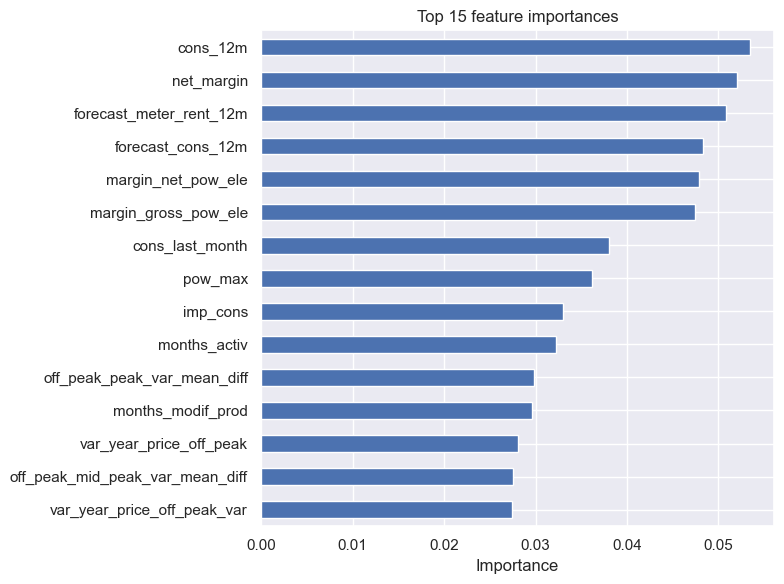

cons_12m                           0.053398
net_margin                         0.052070
forecast_meter_rent_12m            0.050829
forecast_cons_12m                  0.048348
margin_net_pow_ele                 0.047846
margin_gross_pow_ele               0.047445
cons_last_month                    0.037981
pow_max                            0.036178
imp_cons                           0.033000
months_activ                       0.032183
off_peak_peak_var_mean_diff        0.029786
months_modif_prod                  0.029601
var_year_price_off_peak            0.028126
off_peak_mid_peak_var_mean_diff    0.027481
var_year_price_off_peak_var        0.027408
dtype: float64

In [13]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(8, 6))
importances.head(top_n).sort_values().plot(kind='barh')
plt.title(f'Top {top_n} feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(top_n)


In [14]:
# Check how many of the top features are price-related
price_keywords = ['price', 'peak', 'offpeak']
top_features = importances.head(top_n)
price_related = [f for f in top_features.index if any(k in f.lower() for k in price_keywords)]

print(f"{len(price_related)} of the top {top_n} features are price-related:")
for f in price_related:
    print(f"  - {f}  (importance: {importances[f]:.4f})")


4 of the top 15 features are price-related:
  - off_peak_peak_var_mean_diff  (importance: 0.0298)
  - var_year_price_off_peak  (importance: 0.0281)
  - off_peak_mid_peak_var_mean_diff  (importance: 0.0275)
  - var_year_price_off_peak_var  (importance: 0.0274)


In [15]:
# verdict on the original client hypothesis
from IPython.display import Markdown, display

share = len(price_related) / top_n
hypothesis_verdict = (
    "Price-related features dominate the top predictors, which **supports** "
    "the client's hypothesis that price sensitivity is a major driver of churn."
    if share >= 0.5 else
    "Price-related features make up a **minority** of the top predictors. "
    "This suggests price sensitivity, while still a factor, is **not the "
    "primary driver** of churn on its own -- other engineered features "
    "(consumption patterns, tenure, contract/sales-channel signals) appear "
    "to carry more predictive weight."
)

display(Markdown(f'''
### Verdict on the client's price-sensitivity hypothesis

{len(price_related)} of the top {top_n} features ({share:.0%}) by importance are
price-related. {hypothesis_verdict}

This is the headline finding to bring back to the client: price is one input
worth addressing, but retention strategy shouldn't be built around price alone
without also looking at the other top-ranked features above.
'''))



### Verdict on the client's price-sensitivity hypothesis

4 of the top 15 features (27%) by importance are
price-related. Price-related features make up a **minority** of the top predictors. This suggests price sensitivity, while still a factor, is **not the primary driver** of churn on its own -- other engineered features (consumption patterns, tenure, contract/sales-channel signals) appear to carry more predictive weight.

This is the headline finding to bring back to the client: price is one input
worth addressing, but retention strategy shouldn't be built around price alone
without also looking at the other top-ranked features above.
